# Dense vs Sparse Retrieval 비교 분석

- Part 04: RAG 고도화 - Dense / Sparse Retrieval 분석
- 담당: 건호
- chromadb 없이 numpy 코사인 유사도 + rank_bm25로 구현

In [28]:
import json
import re
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from openai import OpenAI
from rank_bm25 import BM25Okapi
from dotenv import load_dotenv

load_dotenv(Path(r"C:\Project\python\02_codeit_project02\.env"))
client = OpenAI()

# 경로 설정
CHUNKS_PATH = Path(r"C:\Project\python\02_codeit_project02\baseline\찬영\고도화1단계(기준)\rag_outputs\b02_prefix_v2_chunks.jsonl")
QUESTIONS_PATH = Path(r"C:\Project\python\02_codeit_project02\evaluation\day3_partA_eval_questions_v1.txt")
EMBEDDINGS_PATH = Path(r"C:\Project\python\02_codeit_project02\dense_sparse_embeddings.npy")
RESULTS_DIR = Path(r"C:\Project\python\02_codeit_project02\dense_sparse_results")
RESULTS_DIR.mkdir(exist_ok=True)

print("설정 완료")

설정 완료


## 1. 청크 로드

In [29]:
chunks = []
with open(CHUNKS_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        chunks.append(json.loads(line))

chunk_texts = [c['contextual_chunk_text'] for c in chunks]
chunk_ids = [c['chunk_id'] for c in chunks]
chunk_files = [c['source_file_name'] for c in chunks]

print(f"청크 수: {len(chunks)}")
print(f"문서 수: {len(set(c['document_id'] for c in chunks))}")

청크 수: 5948
문서 수: 100


## 2. Dense 준비 - 청크 임베딩 생성

In [30]:
EMBEDDING_MODEL = "text-embedding-3-small"
BATCH_SIZE = 100

if EMBEDDINGS_PATH.exists():
    chunk_embeddings = np.load(EMBEDDINGS_PATH)
    print(f"기존 임베딩 로드 완료: {chunk_embeddings.shape}")
else:
    all_embeddings = []
    for i in range(0, len(chunk_texts), BATCH_SIZE):
        batch = chunk_texts[i:i+BATCH_SIZE]
        response = client.embeddings.create(model=EMBEDDING_MODEL, input=batch)
        batch_emb = [item.embedding for item in response.data]
        all_embeddings.extend(batch_emb)
        print(f"[{i+len(batch)}/{len(chunk_texts)}] 임베딩 완료")
    
    chunk_embeddings = np.array(all_embeddings, dtype=np.float32)
    np.save(EMBEDDINGS_PATH, chunk_embeddings)
    print(f"임베딩 저장 완료: {chunk_embeddings.shape}")

# 정규화 (코사인 유사도 계산용)
norms = np.linalg.norm(chunk_embeddings, axis=1, keepdims=True)
chunk_embeddings_norm = chunk_embeddings / norms

기존 임베딩 로드 완료: (5948, 1536)


## 3. Sparse 준비 - BM25 인덱스 생성

In [31]:
def tokenize_korean(text):
    """한국어+영어 토큰화 (공백 + 조사 분리)"""
    text = re.sub(r'[^\w\s가-힣]', ' ', text)
    return text.split()

tokenized_chunks = [tokenize_korean(text) for text in chunk_texts]
bm25 = BM25Okapi(tokenized_chunks)
print(f"BM25 인덱스 생성 완료: {len(tokenized_chunks)}개 문서")

BM25 인덱스 생성 완료: 5948개 문서


## 4. 질문 파싱 (45개)

In [32]:
QUESTION_HEADER_RE = re.compile(r"^Q(?P<num>\d+)(?: \[(?P<turn>\d+)턴])?$")
FIELD_RE = re.compile(r"^\s*([A-Za-z_]+)\s*:\s*(.+?)\s*$")
TYPE_RE = re.compile(r"^TYPE\s+(?P<type_num>\d+)\s*:\s*(?P<label>.+)$")

def parse_questions(path):
    text = path.read_text(encoding='utf-8')
    rows = []
    current = None
    current_type = ""
    current_label = ""
    
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        
        type_match = TYPE_RE.match(line)
        if type_match:
            current_type = f"TYPE {type_match.group('type_num')}"
            current_label = type_match.group('label').strip()
            continue
        
        q_match = QUESTION_HEADER_RE.match(line)
        if q_match:
            if current is not None:
                rows.append(current)
            current = {
                'question_id': f"Q{int(q_match.group('num')):02d}",
                'type_group': current_type,
                'type_label': current_label,
            }
            continue
        
        if current is None:
            continue
        
        field_match = FIELD_RE.match(raw_line)
        if field_match:
            current[field_match.group(1).strip()] = field_match.group(2).strip()
    
    if current is not None:
        rows.append(current)
    
    for row in rows:
        row.setdefault('question', '')
        row.setdefault('ground_truth_doc', '')
        row.setdefault('ground_truth_docs', '')
        row.setdefault('answer_type', '')
    
    return rows

questions = parse_questions(QUESTIONS_PATH)
print(f"질문 수: {len(questions)}")
for t in sorted(set(q['type_group'] for q in questions)):
    count = sum(1 for q in questions if q['type_group'] == t)
    print(f"  {t}: {count}개")

질문 수: 45
  TYPE 1: 12개
  TYPE 2: 10개
  TYPE 3: 13개
  TYPE 4: 10개


## 5. Dense / Sparse 검색 실행

In [33]:
import difflib

TOP_K = 5

def dense_search(query, top_k=TOP_K):
    """코사인 유사도 기반 Dense 검색"""
    resp = client.embeddings.create(model=EMBEDDING_MODEL, input=[query])
    q_emb = np.array(resp.data[0].embedding, dtype=np.float32)
    q_emb = q_emb / np.linalg.norm(q_emb)
    scores = chunk_embeddings_norm @ q_emb
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(int(idx), float(scores[idx])) for idx in top_indices]

def sparse_search(query, top_k=TOP_K):
    """BM25 기반 Sparse 검색"""
    tokens = tokenize_korean(query)
    scores = bm25.get_scores(tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(int(idx), float(scores[idx])) for idx in top_indices]

def normalize_name(text):
    v = str(text or '').lower().strip()
    v = re.sub(r'\s+', '', v)
    v = re.sub(r'[^0-9a-z가-힣._-]+', '', v)
    return v

def check_hit(ground_truth_docs, retrieved_files):
    """정답 문서 적중 여부 확인"""
    if not ground_truth_docs:
        return None, None, None
    
    norm_retrieved = [normalize_name(f) for f in retrieved_files]
    norm_gt = [normalize_name(g) for g in ground_truth_docs]
    
    def matched(target, candidate):
        if not (target and candidate):
            return False
        if target in candidate or candidate in target:
            return True
        return difflib.SequenceMatcher(None, target, candidate).ratio() >= 0.86
    
    # top1 hit
    top1 = int(any(matched(gt, norm_retrieved[0]) for gt in norm_gt)) if norm_retrieved else 0
    
    # topk hit
    hit_count = sum(1 for gt in norm_gt if any(matched(gt, r) for r in norm_retrieved))
    topk = int(hit_count > 0)
    hit_rate = hit_count / len(norm_gt)
    
    # MRR
    mrr = 0.0
    for gt in norm_gt:
        for rank, r in enumerate(norm_retrieved, 1):
            if matched(gt, r):
                mrr = max(mrr, 1.0 / rank)
                break
    
    return top1, topk, hit_rate, mrr

def get_ground_truth_docs(q):
    if q.get('ground_truth_doc'):
        return [q['ground_truth_doc'].strip()]
    if q.get('ground_truth_docs'):
        return [d.strip() for d in q['ground_truth_docs'].split('+') if d.strip()]
    return []

print("검색 함수 준비 완료")

검색 함수 준비 완료


In [34]:
results = []

for i, q in enumerate(questions):
    query = q['question']
    gt_docs = get_ground_truth_docs(q)
    
    # Dense 검색
    dense_results = dense_search(query)
    dense_files = [chunk_files[idx] for idx, _ in dense_results]
    dense_metrics = check_hit(gt_docs, dense_files)
    
    # Sparse 검색
    sparse_results = sparse_search(query)
    sparse_files = [chunk_files[idx] for idx, _ in sparse_results]
    sparse_metrics = check_hit(gt_docs, sparse_files)
    
    row = {
        'question_id': q['question_id'],
        'type_group': q['type_group'],
        'type_label': q['type_label'],
        'answer_type': q.get('answer_type', ''),
        'question': query,
        'ground_truth_doc': ' + '.join(gt_docs) if gt_docs else '',
        # Dense 결과
        'dense_top1_hit': dense_metrics[0] if dense_metrics[0] is not None else '',
        'dense_topk_hit': dense_metrics[1] if dense_metrics[0] is not None else '',
        'dense_hit_rate': round(dense_metrics[2], 4) if dense_metrics[0] is not None else '',
        'dense_mrr': round(dense_metrics[3], 4) if dense_metrics[0] is not None else '',
        'dense_top1_file': dense_files[0] if dense_files else '',
        # Sparse 결과
        'sparse_top1_hit': sparse_metrics[0] if sparse_metrics[0] is not None else '',
        'sparse_topk_hit': sparse_metrics[1] if sparse_metrics[0] is not None else '',
        'sparse_hit_rate': round(sparse_metrics[2], 4) if sparse_metrics[0] is not None else '',
        'sparse_mrr': round(sparse_metrics[3], 4) if sparse_metrics[0] is not None else '',
        'sparse_top1_file': sparse_files[0] if sparse_files else '',
    }
    results.append(row)
    print(f"[{i+1}/{len(questions)}] {q['question_id']} | Dense top1={row['dense_top1_hit']} | Sparse top1={row['sparse_top1_hit']}")

df_results = pd.DataFrame(results)
df_results.to_csv(RESULTS_DIR / 'dense_sparse_per_question.csv', index=False, encoding='utf-8-sig')
print(f"\n질문별 결과 저장 완료: {len(results)}개")

[1/45] Q01 | Dense top1=1 | Sparse top1=1
[2/45] Q02 | Dense top1=1 | Sparse top1=1
[3/45] Q03 | Dense top1=1 | Sparse top1=1
[4/45] Q04 | Dense top1=1 | Sparse top1=1
[5/45] Q05 | Dense top1=1 | Sparse top1=1
[6/45] Q06 | Dense top1=1 | Sparse top1=1
[7/45] Q07 | Dense top1=1 | Sparse top1=1
[8/45] Q08 | Dense top1=1 | Sparse top1=1
[9/45] Q09 | Dense top1=1 | Sparse top1=1
[10/45] Q10 | Dense top1=1 | Sparse top1=1
[11/45] Q11 | Dense top1=1 | Sparse top1=1
[12/45] Q12 | Dense top1=1 | Sparse top1=1
[13/45] Q13 | Dense top1=0 | Sparse top1=0
[14/45] Q14 | Dense top1= | Sparse top1=
[15/45] Q15 | Dense top1= | Sparse top1=
[16/45] Q16 | Dense top1= | Sparse top1=
[17/45] Q17 | Dense top1= | Sparse top1=
[18/45] Q18 | Dense top1= | Sparse top1=
[19/45] Q19 | Dense top1= | Sparse top1=
[20/45] Q20 | Dense top1= | Sparse top1=
[21/45] Q21 | Dense top1= | Sparse top1=
[22/45] Q22 | Dense top1= | Sparse top1=
[23/45] Q23 | Dense top1= | Sparse top1=
[24/45] Q24 | Dense top1= | Sparse top1=

## 6. 비교표 생성

In [35]:
def calc_summary(df, label):
    """Dense / Sparse 요약 통계 계산"""
    # ground_truth가 있는 행만 필터
    has_gt = df[df['ground_truth_doc'] != ''].copy()
    if len(has_gt) == 0:
        return None
    
    return {
        'group': label,
        'question_count': len(df),
        'eval_count': len(has_gt),
        'dense_top1_hit_rate': round(has_gt['dense_top1_hit'].astype(float).mean(), 4) if len(has_gt) > 0 else '',
        'dense_topk_hit_rate': round(has_gt['dense_topk_hit'].astype(float).mean(), 4) if len(has_gt) > 0 else '',
        'dense_avg_mrr': round(has_gt['dense_mrr'].astype(float).mean(), 4) if len(has_gt) > 0 else '',
        'sparse_top1_hit_rate': round(has_gt['sparse_top1_hit'].astype(float).mean(), 4) if len(has_gt) > 0 else '',
        'sparse_topk_hit_rate': round(has_gt['sparse_topk_hit'].astype(float).mean(), 4) if len(has_gt) > 0 else '',
        'sparse_avg_mrr': round(has_gt['sparse_mrr'].astype(float).mean(), 4) if len(has_gt) > 0 else '',
    }

summary_rows = []

# 전체
summary_rows.append(calc_summary(df_results, 'overall'))

# TYPE별
for t in sorted(df_results['type_group'].unique()):
    row = calc_summary(df_results[df_results['type_group'] == t], t)
    if row:
        summary_rows.append(row)

# answer_type별
for at in sorted(df_results['answer_type'].unique()):
    if not at:
        continue
    row = calc_summary(df_results[df_results['answer_type'] == at], f'answer_type:{at}')
    if row:
        summary_rows.append(row)

summary_rows = [r for r in summary_rows if r is not None]
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(RESULTS_DIR / 'dense_sparse_summary.csv', index=False, encoding='utf-8-sig')

print("=" * 80)
print("Dense vs Sparse Retrieval 비교표")
print("=" * 80)
display(df_summary)

Dense vs Sparse Retrieval 비교표


,group,question_count,eval_count,dense_top1_hit_rate,dense_topk_hit_rate,dense_avg_mrr,sparse_top1_hit_rate,sparse_topk_hit_rate,sparse_avg_mrr
0,overall,45,13,0.9231,0.9231,0.9231,0.9231,0.9231,0.9231
1,TYPE 1,12,12,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,TYPE 2,10,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,answer_type:comparison,12,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,answer_type:factual,15,12,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## 7. 시각화 비교

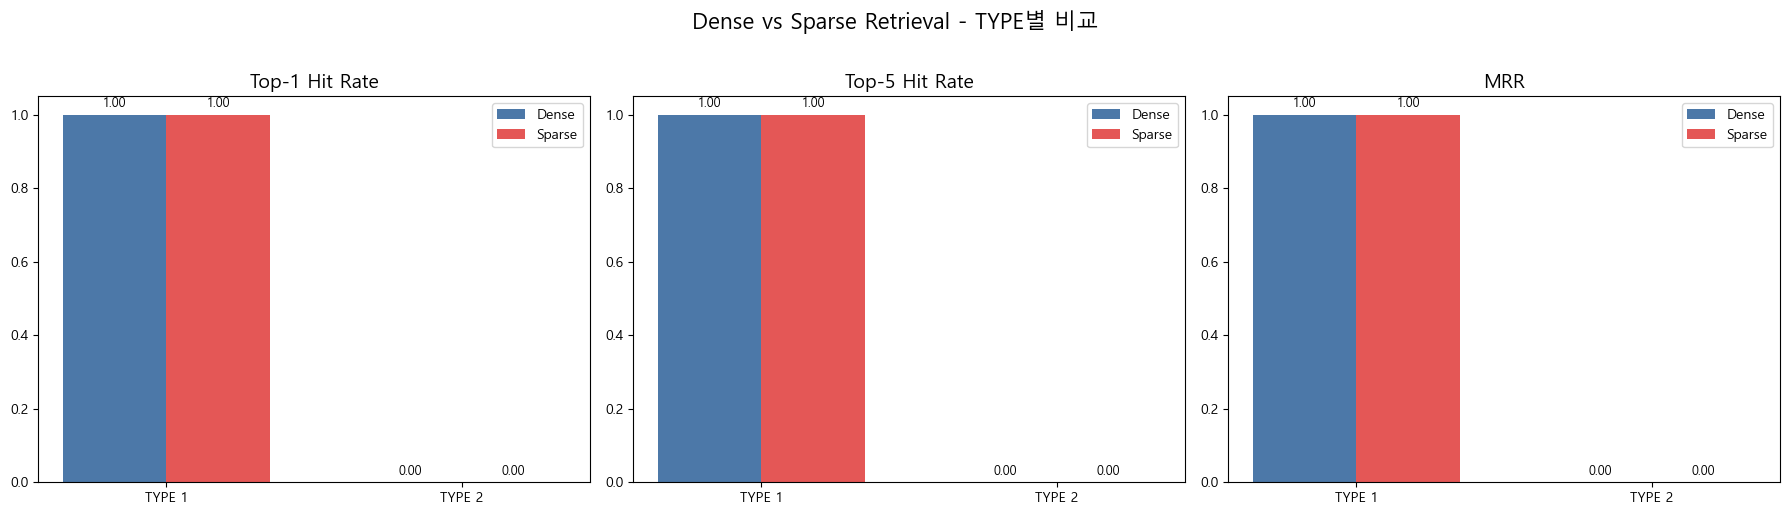

차트 저장 완료


In [36]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# TYPE별 비교 차트
type_rows = df_summary[df_summary['group'].str.startswith('TYPE')].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('top1_hit_rate', 'Top-1 Hit Rate'),
    ('topk_hit_rate', f'Top-{TOP_K} Hit Rate'),
    ('avg_mrr', 'MRR'),
]

x = range(len(type_rows))
labels = type_rows['group'].tolist()
width = 0.35

for ax, (metric_suffix, title) in zip(axes, metrics):
    dense_vals = type_rows[f'dense_{metric_suffix}'].astype(float).tolist()
    sparse_vals = type_rows[f'sparse_{metric_suffix}'].astype(float).tolist()
    
    bars1 = ax.bar([i - width/2 for i in x], dense_vals, width, label='Dense', color='#4C78A8')
    bars2 = ax.bar([i + width/2 for i in x], sparse_vals, width, label='Sparse', color='#E45756')
    
    ax.set_title(title, fontsize=14)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.legend()
    
    for bar in bars1 + bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', fontsize=9)

plt.suptitle('Dense vs Sparse Retrieval - TYPE별 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dense_sparse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("차트 저장 완료")

## 8. Hybrid 검색 + 3종 비교 (Dense vs Sparse vs Hybrid)

In [37]:
def hybrid_search(query, top_k=TOP_K, candidate_k=10, vector_weight=0.7, bm25_weight=0.3, rrf_k=60):
    """Dense + Sparse RRF 결합 Hybrid 검색"""
    dense_results = dense_search(query, top_k=candidate_k)
    sparse_results = sparse_search(query, top_k=candidate_k)
    
    # RRF 점수 계산
    fused = {}
    for rank, (idx, score) in enumerate(dense_results, 1):
        fused[idx] = fused.get(idx, 0.0) + vector_weight * (1.0 / (rrf_k + rank))
    for rank, (idx, score) in enumerate(sparse_results, 1):
        fused[idx] = fused.get(idx, 0.0) + bm25_weight * (1.0 / (rrf_k + rank))
    
    ranked = sorted(fused.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return [(idx, score) for idx, score in ranked]

# 45개 질문에 대해 Dense / Sparse / Hybrid 3종 실행
results_3way = []

for i, q in enumerate(questions):
    query = q['question']
    gt_docs = get_ground_truth_docs(q)
    
    # Dense
    d_results = dense_search(query)
    d_files = [chunk_files[idx] for idx, _ in d_results]
    d_metrics = check_hit(gt_docs, d_files)
    
    # Sparse
    s_results = sparse_search(query)
    s_files = [chunk_files[idx] for idx, _ in s_results]
    s_metrics = check_hit(gt_docs, s_files)
    
    # Hybrid
    h_results = hybrid_search(query)
    h_files = [chunk_files[idx] for idx, _ in h_results]
    h_metrics = check_hit(gt_docs, h_files)
    
    has_gt = d_metrics[0] is not None
    
    row = {
        'question_id': q['question_id'],
        'type_group': q['type_group'],
        'answer_type': q.get('answer_type', ''),
        'question': query[:50],
        'ground_truth_doc': ' + '.join(gt_docs) if gt_docs else '',
        'dense_top1_file': d_files[0],
        'sparse_top1_file': s_files[0],
        'hybrid_top1_file': h_files[0],
        'dense_top1_hit': d_metrics[0] if has_gt else '',
        'sparse_top1_hit': s_metrics[0] if has_gt else '',
        'hybrid_top1_hit': h_metrics[0] if has_gt else '',
        'dense_mrr': round(d_metrics[3], 4) if has_gt else '',
        'sparse_mrr': round(s_metrics[3], 4) if has_gt else '',
        'hybrid_mrr': round(h_metrics[3], 4) if has_gt else '',
    }
    results_3way.append(row)
    
    d_mark = "O" if (has_gt and d_metrics[0]) else ("X" if has_gt else "-")
    s_mark = "O" if (has_gt and s_metrics[0]) else ("X" if has_gt else "-")
    h_mark = "O" if (has_gt and h_metrics[0]) else ("X" if has_gt else "-")
    print(f"[{i+1}/{len(questions)}] {q['question_id']} | D:{d_mark} S:{s_mark} H:{h_mark} | {h_files[0][:40]}")

df_3way = pd.DataFrame(results_3way)
df_3way.to_csv(RESULTS_DIR / 'dense_sparse_hybrid_per_question.csv', index=False, encoding='utf-8-sig')
print(f"\n3종 비교 결과 저장 완료: {len(results_3way)}개")

[1/45] Q01 | D:O S:O H:O | 국민연금공단_2024년 이러닝시스템 운영 용역.hwp
[2/45] Q02 | D:O S:O H:O | 고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
[3/45] Q03 | D:O S:O H:O | 기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.pdf
[4/45] Q04 | D:O S:O H:O | 한국원자력연구원_한국원자력연구원 선량평가시스템 고도화.hwp
[5/45] Q05 | D:O S:O H:O | 한국가스공사_[재공고]차세대 통합정보시스템(ERP) 구축.hwp
[6/45] Q06 | D:O S:O H:O | 서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용
[7/45] Q07 | D:O S:O H:O | 경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hw
[8/45] Q08 | D:O S:O H:O | 인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp
[9/45] Q09 | D:O S:O H:O | 서민금융진흥원_서민금융진흥원 서민금융 채팅 상담시스템 구축.hwp
[10/45] Q10 | D:O S:O H:O | 광주과학기술원_학사시스템 기능개선 사업.hwp
[11/45] Q11 | D:O S:O H:O | 그랜드코리아레저(주)_2024년도 GKL  그룹웨어 시스템 구축 용역.h
[12/45] Q12 | D:O S:O H:O | 국립중앙의료원_(긴급)「2024년도 차세대 응급의료 상황관리시스템 구축.
[13/45] Q13 | D:X S:X H:X | 고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
[14/45] Q14 | D:- S:- H:- | 한국교육과정평가원_국가교육과정정보센터(NCIC) 시스템 운영 및 개선.h
[15/45] Q15 | D:- S:- H:- | (사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.h
[16/45] Q16 | D:- S:- H:- | 국방과학연구소_기록관리시스템 통합 

Dense vs Sparse vs Hybrid - TYPE별 성능 비교


,group,question_count,eval_count,dense_top1_hit_rate,dense_mrr,sparse_top1_hit_rate,sparse_mrr,hybrid_top1_hit_rate,hybrid_mrr,dense_sparse_일치율,hybrid_dense_일치율,hybrid_sparse_일치율
0,overall,45,13,0.9231,0.9231,0.9231,0.9231,0.9231,0.9231,0.5333,0.8222,0.6667
1,TYPE 1,12,12,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000
2,TYPE 2,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.1000,1.0000,0.1000
3,TYPE 3,13,0,-,-,-,-,-,-,0.3077,0.5385,0.6154
4,TYPE 4,10,0,-,-,-,-,-,-,0.7000,0.8000,0.9000


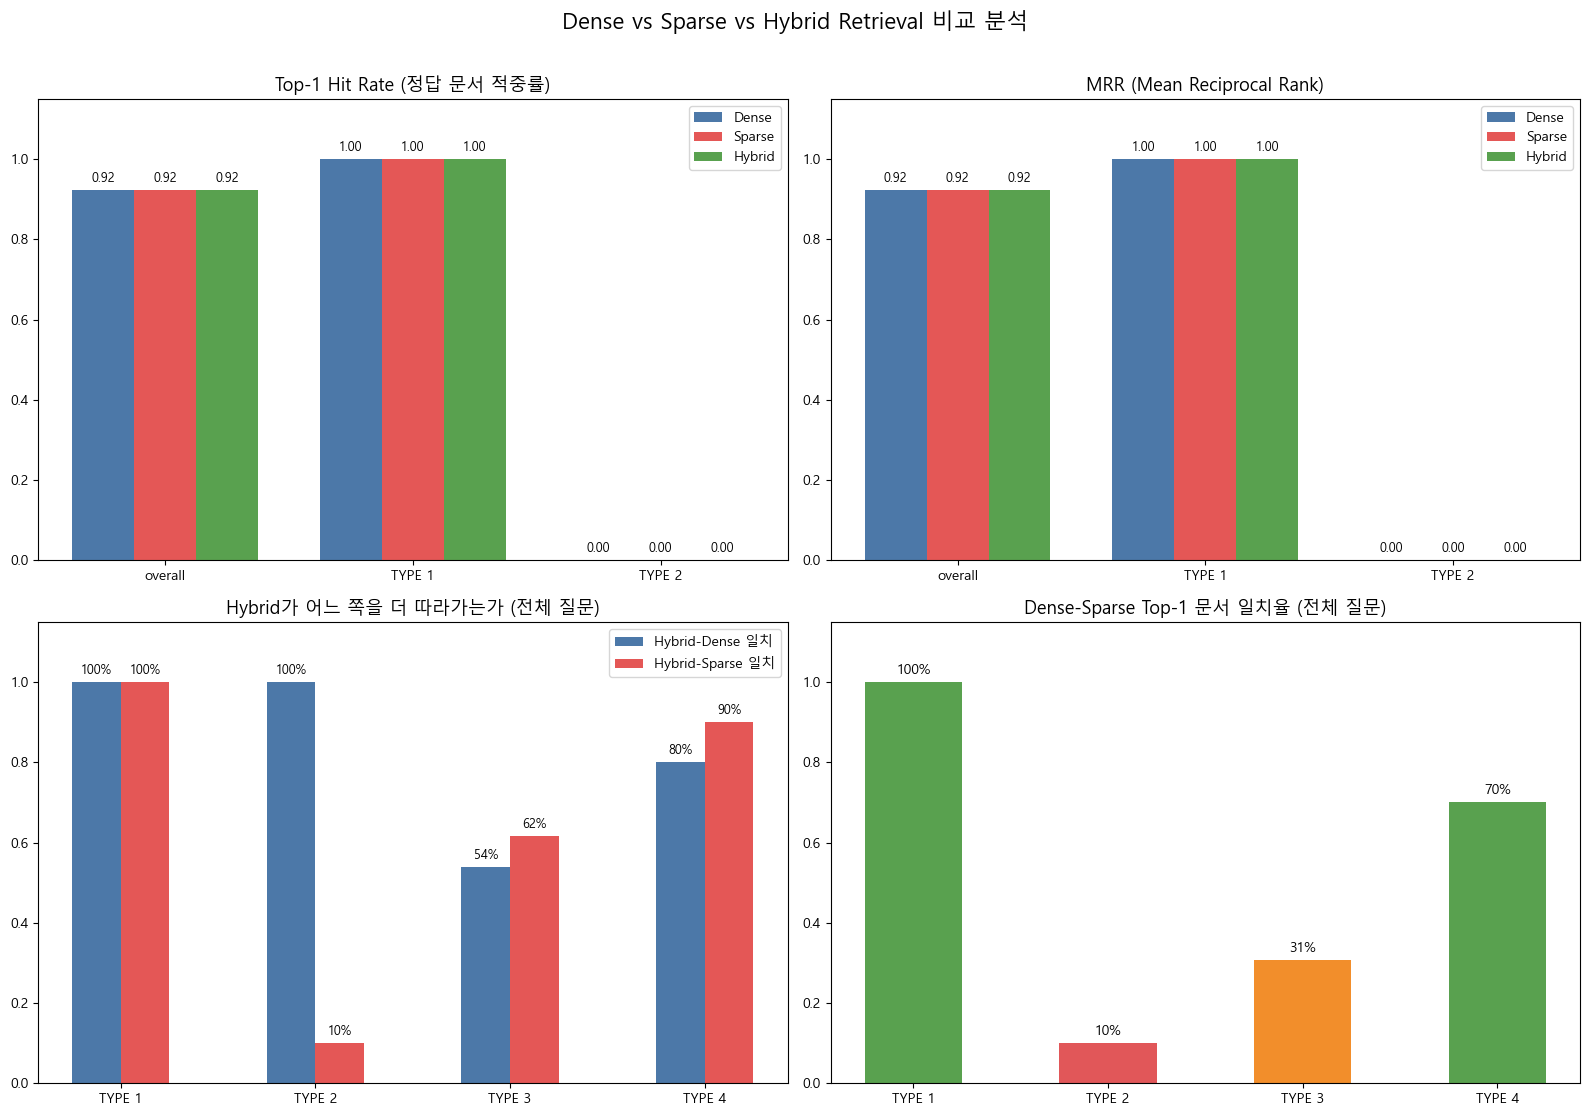

3종 비교 차트 저장 완료


In [38]:
# 3종 비교 요약표 + 차트 (Dense-only vs Sparse-only vs Hybrid)

# ── 1) TYPE별 성능 요약표 ──
def calc_3way_summary(df, label):
    """Dense / Sparse / Hybrid 각각의 성능 지표 계산"""
    has_gt = df[df['ground_truth_doc'] != ''].copy()
    n_total = len(df)
    n_eval = len(has_gt)
    
    row = {'group': label, 'question_count': n_total, 'eval_count': n_eval}
    
    if n_eval > 0:
        for method in ['dense', 'sparse', 'hybrid']:
            row[f'{method}_top1_hit_rate'] = round(has_gt[f'{method}_top1_hit'].astype(float).mean(), 4)
            row[f'{method}_mrr'] = round(has_gt[f'{method}_mrr'].astype(float).mean(), 4)
    else:
        for method in ['dense', 'sparse', 'hybrid']:
            row[f'{method}_top1_hit_rate'] = '-'
            row[f'{method}_mrr'] = '-'
    
    # 전체 질문 대상 경향 분석 (ground_truth 불필요)
    ds_match = (df['dense_top1_file'] == df['sparse_top1_file']).mean()
    dh_match = (df['dense_top1_file'] == df['hybrid_top1_file']).mean()
    sh_match = (df['sparse_top1_file'] == df['hybrid_top1_file']).mean()
    row['dense_sparse_일치율'] = round(ds_match, 4)
    row['hybrid_dense_일치율'] = round(dh_match, 4)
    row['hybrid_sparse_일치율'] = round(sh_match, 4)
    
    return row

summary_3way = []
summary_3way.append(calc_3way_summary(df_3way, 'overall'))
for t in sorted(df_3way['type_group'].unique()):
    summary_3way.append(calc_3way_summary(df_3way[df_3way['type_group'] == t], t))

df_3way_summary = pd.DataFrame(summary_3way)
df_3way_summary.to_csv(RESULTS_DIR / 'three_way_type_summary.csv', index=False, encoding='utf-8-sig')

print("=" * 80)
print("Dense vs Sparse vs Hybrid - TYPE별 성능 비교")
print("=" * 80)
display(df_3way_summary)

# ── 2) 차트 2x2: 성능 비교 + 경향 분석 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
width = 0.25

# --- 차트 A: Dense / Sparse / Hybrid 성능 직접 비교 (ground_truth 있는 TYPE + overall) ---
chart_perf = df_3way_summary[df_3way_summary['eval_count'] > 0].copy()
labels_a = chart_perf['group'].tolist()
x_a = range(len(labels_a))

# A-1: Top-1 Hit Rate
ax = axes[0][0]
d_vals = chart_perf['dense_top1_hit_rate'].astype(float).tolist()
s_vals = chart_perf['sparse_top1_hit_rate'].astype(float).tolist()
h_vals = chart_perf['hybrid_top1_hit_rate'].astype(float).tolist()
bars_d = ax.bar([i - width for i in x_a], d_vals, width, label='Dense', color='#4C78A8')
bars_s = ax.bar(list(x_a), s_vals, width, label='Sparse', color='#E45756')
bars_h = ax.bar([i + width for i in x_a], h_vals, width, label='Hybrid', color='#59A14F')
ax.set_title('Top-1 Hit Rate (정답 문서 적중률)', fontsize=13)
ax.set_xticks(list(x_a)); ax.set_xticklabels(labels_a)
ax.set_ylim(0, 1.15); ax.legend()
for bar in list(bars_d) + list(bars_s) + list(bars_h):
    ht = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, ht + 0.02, f'{ht:.2f}', ha='center', fontsize=9)

# A-2: MRR
ax = axes[0][1]
d_mrr = chart_perf['dense_mrr'].astype(float).tolist()
s_mrr = chart_perf['sparse_mrr'].astype(float).tolist()
h_mrr = chart_perf['hybrid_mrr'].astype(float).tolist()
bars_d = ax.bar([i - width for i in x_a], d_mrr, width, label='Dense', color='#4C78A8')
bars_s = ax.bar(list(x_a), s_mrr, width, label='Sparse', color='#E45756')
bars_h = ax.bar([i + width for i in x_a], h_mrr, width, label='Hybrid', color='#59A14F')
ax.set_title('MRR (Mean Reciprocal Rank)', fontsize=13)
ax.set_xticks(list(x_a)); ax.set_xticklabels(labels_a)
ax.set_ylim(0, 1.15); ax.legend()
for bar in list(bars_d) + list(bars_s) + list(bars_h):
    ht = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, ht + 0.02, f'{ht:.2f}', ha='center', fontsize=9)

# --- 차트 B: Hybrid 경향 분석 (전체 45개 질문, ground_truth 불필요) ---
chart_all = df_3way_summary[df_3way_summary['group'] != 'overall'].copy()
labels_b = chart_all['group'].tolist()
x_b = range(len(labels_b))

# B-1: Hybrid가 Dense/Sparse 어느 쪽을 더 따라가는가
ax = axes[1][0]
dh = chart_all['hybrid_dense_일치율'].astype(float).tolist()
sh = chart_all['hybrid_sparse_일치율'].astype(float).tolist()
bars1 = ax.bar([i - width/2 for i in x_b], dh, width, label='Hybrid-Dense 일치', color='#4C78A8')
bars2 = ax.bar([i + width/2 for i in x_b], sh, width, label='Hybrid-Sparse 일치', color='#E45756')
ax.set_title('Hybrid가 어느 쪽을 더 따라가는가 (전체 질문)', fontsize=13)
ax.set_xticks(list(x_b)); ax.set_xticklabels(labels_b)
ax.set_ylim(0, 1.15); ax.legend()
for bar in list(bars1) + list(bars2):
    ht = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, ht + 0.02, f'{ht:.0%}', ha='center', fontsize=9)

# B-2: Dense-Sparse Top-1 문서 일치율
ax = axes[1][1]
ds = chart_all['dense_sparse_일치율'].astype(float).tolist()
colors = ['#59A14F' if v >= 0.7 else '#F28E2B' if v >= 0.3 else '#E15759' for v in ds]
bars = ax.bar(x_b, ds, width=0.5, color=colors)
ax.set_title('Dense-Sparse Top-1 문서 일치율 (전체 질문)', fontsize=13)
ax.set_xticks(list(x_b)); ax.set_xticklabels(labels_b)
ax.set_ylim(0, 1.15)
for bar in bars:
    ht = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, ht + 0.02, f'{ht:.0%}', ha='center', fontsize=10)

plt.suptitle('Dense vs Sparse vs Hybrid Retrieval 비교 분석', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'three_way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("3종 비교 차트 저장 완료")